## Removing chaperones doesnot disrupts network structure.

In [5]:
# ============================================================
# CELL 1: IMPORTS AND BASIC HELPERS
# ============================================================

import random
import math
from typing import Iterable, List, Dict, Tuple, Sequence
import pandas as pd
import numpy as np
import networkx as nx
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from typing import Iterable, List, Dict, Tuple, Sequence, Optional, Set

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Helper: approximate average shortest path length by sampling
def approximate_path_length(G: nx.Graph, n_samples: int = 100, seed: int = 42) -> float:
    """Estimate average shortest-path length by sampling a limited number of source nodes."""
    if G.number_of_nodes() == 0:
        return float("nan")
    rng = random.Random(seed)
    nodes_list = list(G.nodes())
    sample_nodes = nodes_list if len(nodes_list) <= n_samples else rng.sample(nodes_list, n_samples)
    dists = []
    for node in sample_nodes:
        lengths = nx.single_source_shortest_path_length(G, node)
        dists.extend(lengths.values())
    return float(sum(dists)) / len(dists)

# Helper: compute basic metrics after a set of nodes has been removed
def compute_metrics_after_removal(G: nx.Graph, removed_nodes: Sequence[str], sample_size: int = 100) -> Dict[str, float]:
    """
    Given a graph and a list of nodes to remove, return basic topological metrics of the remaining LCC.
    
    Parameters
    ----------
    G : nx.Graph
        Original graph.
    removed_nodes : list-like
        Nodes to delete.
    sample_size : int
        Number of nodes to sample when approximating path length.
        
    Returns
    -------
    metrics : dict
        Contains:
        - 'lcc_size': number of nodes in largest connected component
        - 'n_components': number of connected components in the remaining graph
        - 'efficiency': global efficiency of the LCC
        - 'transitivity': transitivity (global clustering) of the LCC
        - 'path_length': approximate average shortest path length of the LCC
    """
    H = G.copy()
    H.remove_nodes_from(removed_nodes)
    # If graph is empty after removals
    if H.number_of_nodes() == 0:
        return {
            "lcc_size": 0,
            "n_components": 0,
            "efficiency": float("nan"),
            "transitivity": float("nan"),
            "path_length": float("nan")
        }
    # Largest connected component (LCC)
    components = list(nx.connected_components(H))
    lcc_nodes = max(components, key=len)
    H_lcc = H.subgraph(lcc_nodes).copy()
    return {
        "lcc_size": H_lcc.number_of_nodes(),
        "n_components": len(components),
        "efficiency": nx.global_efficiency(H_lcc),
        "transitivity": nx.transitivity(H_lcc),
        "path_length": approximate_path_length(H_lcc, n_samples=sample_size)
    }

In [6]:
# ============================================================
# CELL 2: LOAD DATA AND DEFINE CHAPERONES
# ============================================================

# Paths to data – adjust to your file locations
DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"
nodes_path = f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl"
edges_path = f"{DATA_PATH1}The_Yeast_Interactome_edges.csv"

# Load node and edge tables
nodes_df = pd.read_pickle(nodes_path)
edges_df = pd.read_csv(edges_path)

# Build undirected graph from edges connecting valid nodes
valid_nodes = set(nodes_df["node"])
edges_clean = edges_df[["source", "target"]].dropna().copy()
edges_clean = edges_clean[
    edges_clean["source"].isin(valid_nodes) &
    edges_clean["target"].isin(valid_nodes)
]
edges_clean = edges_clean[edges_clean["source"] != edges_clean["target"]]

G_full = nx.from_pandas_edgelist(
    edges_clean,
    source="source",
    target="target",
    create_using=nx.Graph()
)
# Add all node attributes to the graph
attr_dict = nodes_df.set_index("node").to_dict(orient="index")
nx.set_node_attributes(G_full, attr_dict)

# Restrict to the largest connected component (LCC)
largest_cc_nodes = max(nx.connected_components(G_full), key=len)
G_lcc = G_full.subgraph(largest_cc_nodes).copy()

# Extract curated chaperones
all_chaperones = set()
for lst in nodes_df["interacting_chaperones"]:
    if isinstance(lst, (list, set, tuple)):
        all_chaperones.update(lst)
# Mark chaperones in node table
nodes_df["is_chaperone"] = nodes_df["node"].isin(all_chaperones)
chaperone_nodes = set(nodes_df.loc[nodes_df["is_chaperone"], "node"])
chaperone_nodes = chaperone_nodes.intersection(G_lcc.nodes())

print(f"Number of nodes in LCC: {G_lcc.number_of_nodes()}")
print(f"Number of chaperones in LCC: {len(chaperone_nodes)}")

Number of nodes in LCC: 3839
Number of chaperones in LCC: 65


In [7]:
# ============================================================
# CELL 3: COMPUTE CENTRALITY MEASURES FOR TARGETED REMOVAL
# ============================================================

# We compute several centrality measures used for ranking nodes in attack simulations.
degree_dict = dict(G_lcc.degree())
betweenness_dict = nx.betweenness_centrality(G_lcc, normalized=True, endpoints=False)
closeness_dict = nx.closeness_centrality(G_lcc)
eigenvector_dict = nx.eigenvector_centrality(G_lcc, max_iter=1000, tol=1e-06)

# Build a DataFrame for easy sorting
centrality_df = pd.DataFrame({
    "node": list(G_lcc.nodes()),
    "degree": [degree_dict[n] for n in G_lcc.nodes()],
    "betweenness": [betweenness_dict[n] for n in G_lcc.nodes()],
    "closeness": [closeness_dict[n] for n in G_lcc.nodes()],
    "eigenvector": [eigenvector_dict[n] for n in G_lcc.nodes()],
})
centrality_df["is_chaperone"] = centrality_df["node"].isin(chaperone_nodes)

centrality_df.head()

,node,degree,betweenness,closeness,eigenvector,is_chaperone
0,YKL063C,20,0.002722,0.265606,0.000072,False
1,YDL223C,57,0.014686,0.309816,0.000536,False
2,YPL036W,117,0.061911,0.334408,0.004472,False
3,YPL050C,29,0.000766,0.251458,0.000008,False
4,YJR148W,32,0.002642,0.284233,0.000093,False


In [9]:
# ============================================================
# CELL 4: ATTACK SIMULATION HELPERS
# ============================================================

def simulate_removal_sequence(
    G: nx.Graph,
    removal_sequence: List[str],
    sample_size: int = 100
) -> List[Dict[str, float]]:
    """
    Given a specific ordered list of nodes to remove, compute metrics after each removal step.
    Returns a list of metric dicts, one per step.
    """
    results = []
    for i in tqdm(range(len(removal_sequence)), desc="Removing nodes"):
        removed = removal_sequence[: i + 1]
        metrics = compute_metrics_after_removal(G, removed_nodes=removed, sample_size=sample_size)
        metrics["nodes_removed"] = i + 1
        results.append(metrics)
    return results

def simulate_random_removals(
    G: nx.Graph,
    num_remove: int,
    n_trials: int = 50,
    sample_size: int = 100,
    restrict_to_nodes: Optional[Set[str]] = None,
    seed: int = 42
) -> Dict[str, np.ndarray]:
    """
    Simulate random node removal multiple times and return average metric curves.
    
    If restrict_to_nodes is None, nodes are sampled from the entire LCC; otherwise,
    only nodes in restrict_to_nodes are considered.
    """
    rng = random.Random(seed)
    # Preallocate arrays to accumulate results
    # We'll store metric arrays of shape (n_trials, num_remove)
    lcc_sizes = np.zeros((n_trials, num_remove), dtype=float)
    efficiencies = np.zeros_like(lcc_sizes, dtype=float)
    transitivity_vals = np.zeros_like(lcc_sizes, dtype=float)
    path_lengths = np.zeros_like(lcc_sizes, dtype=float)
    n_components_vals = np.zeros_like(lcc_sizes, dtype=float)

    node_pool = list(restrict_to_nodes) if restrict_to_nodes is not None else list(G.nodes())

    for trial in tqdm(range(n_trials), desc="Random attack trials"):
        removal_sequence = rng.sample(node_pool, k=num_remove)
        for step in range(num_remove):
            removed_nodes = removal_sequence[: step + 1]
            metrics = compute_metrics_after_removal(G, removed_nodes=removed_nodes, sample_size=sample_size)
            lcc_sizes[trial, step] = metrics["lcc_size"]
            efficiencies[trial, step] = metrics["efficiency"]
            transitivity_vals[trial, step] = metrics["transitivity"]
            path_lengths[trial, step] = metrics["path_length"]
            n_components_vals[trial, step] = metrics["n_components"]

    # Compute mean ± SD across trials
    results = {
        "nodes_removed": np.arange(1, num_remove + 1),
        "lcc_size_mean": lcc_sizes.mean(axis=0),
        "lcc_size_sd": lcc_sizes.std(axis=0),
        "efficiency_mean": efficiencies.mean(axis=0),
        "efficiency_sd": efficiencies.std(axis=0),
        "transitivity_mean": transitivity_vals.mean(axis=0),
        "transitivity_sd": transitivity_vals.std(axis=0),
        "path_length_mean": path_lengths.mean(axis=0),
        "path_length_sd": path_lengths.std(axis=0),
        "n_components_mean": n_components_vals.mean(axis=0),
        "n_components_sd": n_components_vals.std(axis=0),
    }
    return results

In [10]:
# ============================================================
# CELL 5: DEFINE REMOVAL STRATEGIES
# ============================================================

# Number of chaperones in LCC (we remove up to this many)
k = len(chaperone_nodes)

# Strategy 1: Targeted removal of chaperones by descending degree
chap_by_degree = (
    centrality_df.loc[centrality_df["is_chaperone"]]
    .sort_values("degree", ascending=False)["node"]
    .tolist()
)[:k]

# Strategy 2: Targeted removal of chaperones by descending closeness
chap_by_closeness = (
    centrality_df.loc[centrality_df["is_chaperone"]]
    .sort_values("closeness", ascending=False)["node"]
    .tolist()
)[:k]

# Strategy 3: Random removal of chaperones (will sample within simulate_random_removals)

# Strategy 4: Random removal of general nodes (select any nodes in LCC)

print(f"Number of chaperones to remove: {k}")
print("Example top 5 chaperones by degree:", chap_by_degree[:5])
print("Example top 5 chaperones by closeness:", chap_by_closeness[:5])

Number of chaperones to remove: 65
Example top 5 chaperones by degree: ['YGR285C', 'YLL024C', 'YHR064C', 'YAL005C', 'YJR045C']
Example top 5 chaperones by closeness: ['YLL024C', 'YAL005C', 'YGR285C', 'YNL007C', 'YER103W']


In [11]:
# ============================================================
# CELL 6: RUN ATTACK SIMULATIONS
# ============================================================

# Set parameters for simulations
n_trials = 30     # number of random trials for averaging
sample_size = 200 # path-length sampling size

# 6A. Targeted removal by degree (chaperones)
print("\n=== Targeted removal: chaperones by degree ===")
results_deg = simulate_removal_sequence(G_lcc, chap_by_degree, sample_size=sample_size)

# 6B. Targeted removal by closeness (chaperones)
print("\n=== Targeted removal: chaperones by closeness ===")
results_close = simulate_removal_sequence(G_lcc, chap_by_closeness, sample_size=sample_size)

# 6C. Random removal of chaperones (average across trials)
print("\n=== Random removal of chaperones ===")
random_chap_results = simulate_random_removals(
    G_lcc, num_remove=k, n_trials=n_trials, sample_size=sample_size, restrict_to_nodes=chaperone_nodes, seed=123
)

# 6D. Random removal of any nodes (control)
print("\n=== Random removal of nodes (control) ===")
random_all_results = simulate_random_removals(
    G_lcc, num_remove=k, n_trials=n_trials, sample_size=sample_size, restrict_to_nodes=None, seed=456
)


=== Targeted removal: chaperones by degree ===


Removing nodes:   0%|          | 0/65 [00:00<?, ?it/s]


=== Targeted removal: chaperones by closeness ===


Removing nodes:   0%|          | 0/65 [00:00<?, ?it/s]


=== Random removal of chaperones ===


Random attack trials:   0%|          | 0/30 [00:00<?, ?it/s]


=== Random removal of nodes (control) ===


Random attack trials:   0%|          | 0/30 [00:00<?, ?it/s]

In [12]:
# ============================================================
# CELL 7: CONVERT TARGETED RESULTS TO DATAFRAMES
# ============================================================

# Convert lists of dictionaries from targeted simulations into pandas DataFrames
df_deg = pd.DataFrame(results_deg)
df_close = pd.DataFrame(results_close)

# For the random results, the function already returns arrays; convert to DataFrame
df_random_chap = pd.DataFrame(random_chap_results)
df_random_all = pd.DataFrame(random_all_results)

df_deg.head()

,lcc_size,n_components,efficiency,transitivity,path_length,nodes_removed
0,3838,1,0.257288,0.536240,4.162021,1
1,3836,2,0.256950,0.537526,4.183276,2
2,3835,2,0.256813,0.538767,4.165520,3
3,3830,6,0.256496,0.539649,4.189884,4
4,3829,6,0.256399,0.540012,4.209124,5


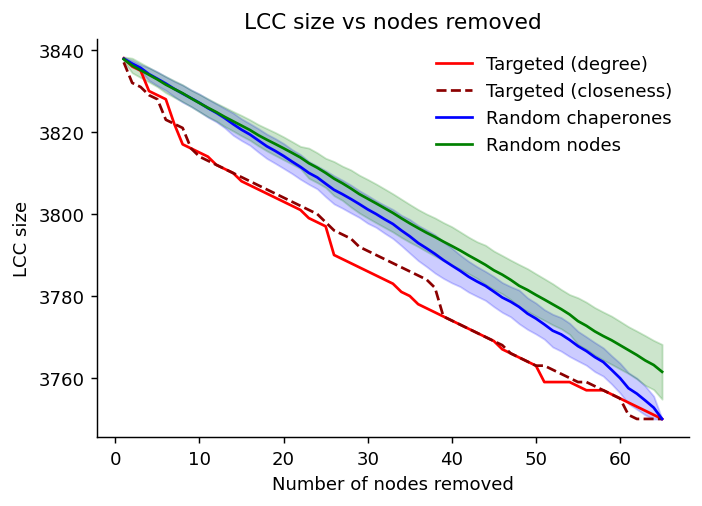

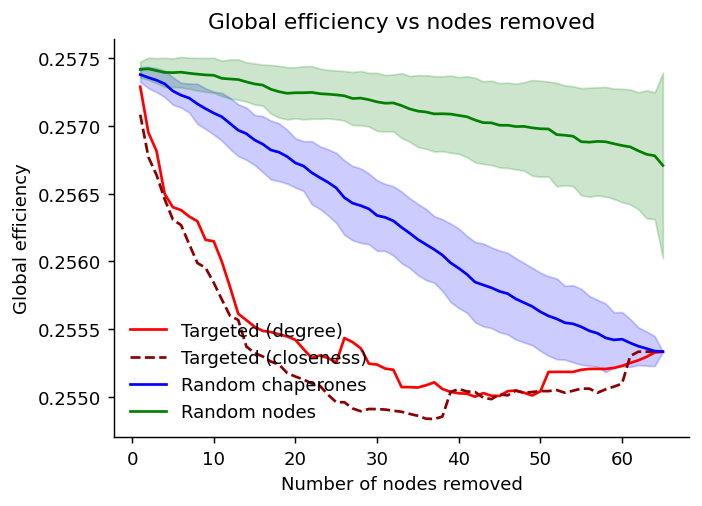

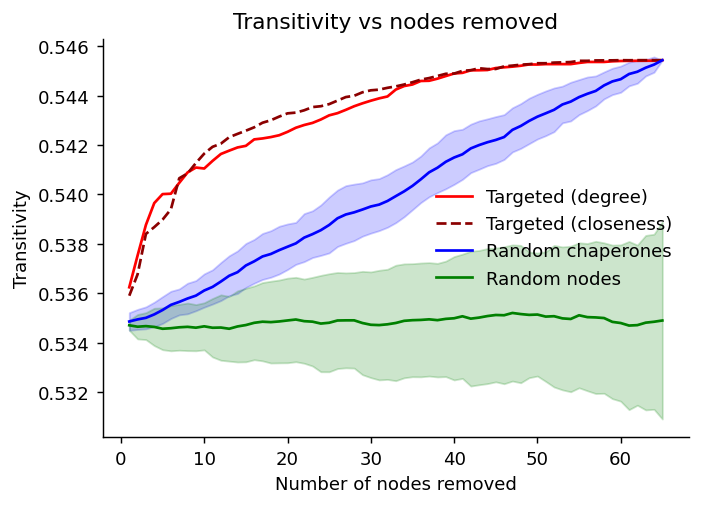

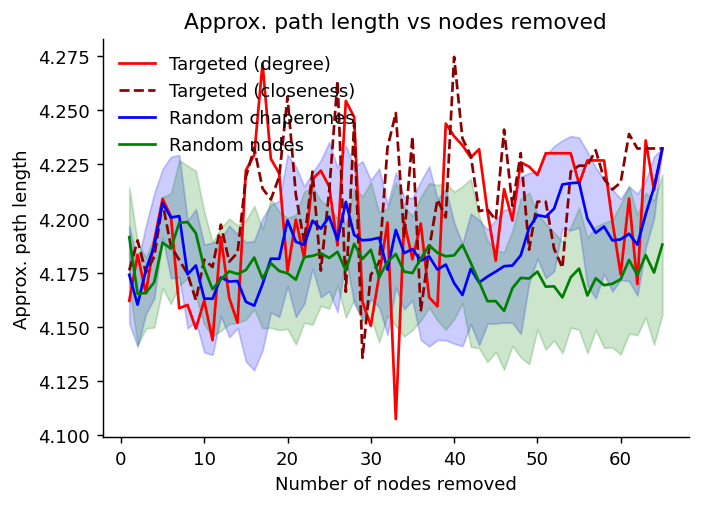

In [13]:
# ============================================================
# CELL 8: PLOT ROBUSTNESS CURVES
# ============================================================

# Helper plotting function
def plot_metric(df_target_deg, df_target_clos, df_rand_chap, df_rand_all, metric_key, ylabel):
    """Plot a metric against the number of nodes removed for four attack strategies."""
    plt.figure(figsize=(5.5, 4))
    
    # Targeted (degree)
    plt.plot(df_target_deg["nodes_removed"], df_target_deg[metric_key], label="Targeted (degree)", color="red")
    # Targeted (closeness)
    plt.plot(df_target_clos["nodes_removed"], df_target_clos[metric_key], label="Targeted (closeness)", color="darkred", linestyle="--")
    
    # Random chaperones (mean ± sd)
    nodes_removed = df_rand_chap["nodes_removed"]
    mean_vals = df_rand_chap[f"{metric_key}_mean"]
    sd_vals = df_rand_chap[f"{metric_key}_sd"]
    plt.plot(nodes_removed, mean_vals, label="Random chaperones", color="blue")
    plt.fill_between(nodes_removed, mean_vals - sd_vals, mean_vals + sd_vals, color="blue", alpha=0.2)
    
    # Random all nodes (mean ± sd)
    mean_vals_all = df_rand_all[f"{metric_key}_mean"]
    sd_vals_all = df_rand_all[f"{metric_key}_sd"]
    plt.plot(nodes_removed, mean_vals_all, label="Random nodes", color="green")
    plt.fill_between(nodes_removed, mean_vals_all - sd_vals_all, mean_vals_all + sd_vals_all, color="green", alpha=0.2)

    plt.xlabel("Number of nodes removed")
    plt.ylabel(ylabel)
    plt.legend(frameon=False)
    plt.title(ylabel + " vs nodes removed")
    plt.tight_layout()
    plt.show()

# Plot LCC size
plot_metric(df_deg, df_close, df_random_chap, df_random_all, metric_key="lcc_size", ylabel="LCC size")

# Plot global efficiency
plot_metric(df_deg, df_close, df_random_chap, df_random_all, metric_key="efficiency", ylabel="Global efficiency")

# Plot transitivity (global clustering)
plot_metric(df_deg, df_close, df_random_chap, df_random_all, metric_key="transitivity", ylabel="Transitivity")

# Plot approximate path length
plot_metric(df_deg, df_close, df_random_chap, df_random_all, metric_key="path_length", ylabel="Approx. path length")

### Chaperones do not hold the interactome together as global connectors.

- Targeted removal shrinks the LCC slightly faster than random removal. But the difference is small. Even after removing all 65 chaperones, the LCC barely shrinks. Why? Because the network has 3839 nodes. Removing 65 nodes is only 1.7% of the network. So we do not expect collapse. This is normal.
  
- Removing chaperones disrupts information flow more than random nodes. But the effect is still modest. This again fits the hypothesis. Chaperones affect local communication efficiency, not global connectivity.

- Removing chaperones increases clustering. Why? Because you are removing hub-like nodes. Classic network property: Removing hubs → remaining network becomes more locally clustered. Because hubs connect distant regions. When you remove them: triangles remain, long-range edges disappear. So clustering goes up. This is expected behavior for hub removal. And it confirms: Chaperones behave like hub-like nodes inside modules.

- Chaperones help maintain efficient communication pathways. But they are not essential bridges.

#### Interpreting robustness curves

- **LCC size**: A steep decline indicates that the network disintegrates quickly.  If removing chaperones (red curves) causes the largest connected component to shrink faster than random removals (blue/green), this means chaperones are structurally important for overall connectivity.

- **Global efficiency**: Efficiency measures how easily information can flow through the network.  A sharper drop in efficiency for targeted chaperone removal indicates that chaperones sustain the network’s short path lengths.

- **Transitivity**: Declining transitivity suggests that clustering is being lost.  If transitivity decays more rapidly for chaperone removal, chaperones are critical to maintaining clustering.

- **Approximate path length**: Rising path length means average distances increase.  Compare how quickly path lengths grow under different removal strategies.

**A key result to look for**: targeted removal of the most central chaperones should disrupt the network much more than random removal of an equivalent number of nodes.  If random removal of non-chaperones barely affects metrics, that further highlights the chaperones’ importance.

Top 5 by betweenness: ['YLL024C', 'YLR259C', 'YAL005C', 'YJL008C', 'YLR216C']
Top 5 by eigenvector: ['YGR285C', 'YNL227C', 'YHR064C', 'YLR216C', 'YJR045C']


Removing nodes:   0%|          | 0/65 [00:00<?, ?it/s]

Removing nodes:   0%|          | 0/65 [00:00<?, ?it/s]

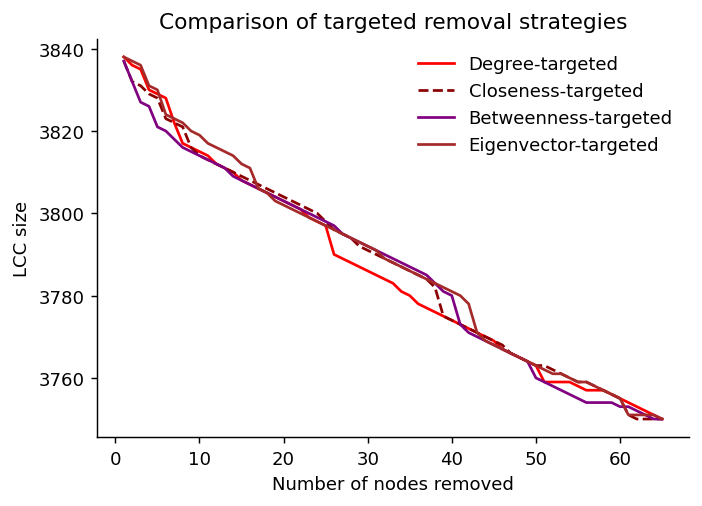

In [14]:
# ============================================================
# CELL 10: ADDITIONAL TARGETED ATTACKS (OPTIONAL)
# ============================================================

# Targeted by betweenness centrality
chap_by_betweenness = (
    centrality_df.loc[centrality_df["is_chaperone"]]
    .sort_values("betweenness", ascending=False)["node"]
    .tolist()
)[:k]
print("Top 5 by betweenness:", chap_by_betweenness[:5])

# Targeted by eigenvector centrality
chap_by_eigen = (
    centrality_df.loc[centrality_df["is_chaperone"]]
    .sort_values("eigenvector", ascending=False)["node"]
    .tolist()
)[:k]
print("Top 5 by eigenvector:", chap_by_eigen[:5])

# Simulate removal using these new orderings
results_betw = simulate_removal_sequence(G_lcc, chap_by_betweenness, sample_size=sample_size)
results_eig  = simulate_removal_sequence(G_lcc, chap_by_eigen, sample_size=sample_size)

df_betw = pd.DataFrame(results_betw)
df_eig  = pd.DataFrame(results_eig)

# Plot LCC size for these additional strategies vs degree/closeness strategies
plt.figure(figsize=(5.5, 4))
plt.plot(df_deg["nodes_removed"], df_deg["lcc_size"], label="Degree-targeted", color="red")
plt.plot(df_close["nodes_removed"], df_close["lcc_size"], label="Closeness-targeted", color="darkred", linestyle="--")
plt.plot(df_betw["nodes_removed"], df_betw["lcc_size"], label="Betweenness-targeted", color="purple")
plt.plot(df_eig["nodes_removed"], df_eig["lcc_size"], label="Eigenvector-targeted", color="brown")
plt.xlabel("Number of nodes removed")
plt.ylabel("LCC size")
plt.legend(frameon=False)
plt.title("Comparison of targeted removal strategies")
plt.tight_layout()
plt.show()